In [1]:
# Notebooks run from the notebooks folder, so the src folder is added to the path.
import sys
from pathlib import Path

src_folder = Path.cwd().parent / "src"
sys.path.insert(0, str(src_folder))

In [2]:
# Reloads edited modules in src without restarting the kernel.
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import config

In [4]:
from prepare import load_chips
from metrics import split_chips, score_prediction
from features import build_features_for_chips, FEATURE_NAMES

chips = load_chips()
train_chips, val_chips, test_chips = split_chips(chips)

train_features, train_answers = build_features_for_chips(train_chips)
print("Training table shape:", train_features.shape)

# A random sample of 2 million pixels is used to reduce training time.
random_generator = np.random.default_rng(42)

sample_size = 2000000
if len(train_features) < sample_size:
    sample_size = len(train_features)

sample_positions = random_generator.choice(
    len(train_features),
    size=sample_size,
    replace=False,        # Sampling without replacement
)

train_features = train_features[sample_positions]
train_answers = train_answers[sample_positions]

print("After sampling:", train_features.shape)
print("Fraction that is canopy:", round(train_answers.mean(), 3))

Training tiles:   1127
Validation tiles: 392
Test tiles:       392
Training table shape: (73859072, 7)
After sampling: (2000000, 7)
Fraction that is canopy: 0.264


In [5]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,          # Number of trees
    max_depth=20,              # Limits depth to prevent overfitting
    min_samples_leaf=5,        # Minimum pixels per leaf
    class_weight="balanced",   # Offsets the class imbalance
    n_jobs=-1,                 # Uses all CPU cores
    random_state=42,           # Reproducible results
)

model.fit(train_features, train_answers)
print("Done.")

Done.


In [6]:
# Validation data.
val_features, val_answers = build_features_for_chips(val_chips)

# Model A uses spectral features only (the first five columns).
model_no_texture = RandomForestClassifier(
    n_estimators=200, max_depth=20, min_samples_leaf=5,
    class_weight="balanced", n_jobs=-1, random_state=42,
)
model_no_texture.fit(train_features[:, :5], train_answers)

prediction_a = model_no_texture.predict(val_features[:, :5])
scores_a = score_prediction(prediction_a, val_answers)

# Model B uses spectral and texture features.
prediction_b = model.predict(val_features)
scores_b = score_prediction(prediction_b, val_answers)

print("Validation results")
print("  Color only:      IoU", round(scores_a["iou"], 3))
print("  Color + texture: IoU", round(scores_b["iou"], 3))
print("  Difference:      ", round(scores_b["iou"] - scores_a["iou"], 3))

Validation results
  Color only:      IoU 0.58
  Color + texture: IoU 0.591
  Difference:       0.011


Texture did not affect the IoU that much.

In [7]:
test_features, test_answers = build_features_for_chips(test_chips)

test_prediction = model.predict(test_features)
forest_scores = score_prediction(test_prediction, test_answers)

# The color-only model is also scored on test, so every reported result uses the same tiles.
test_prediction_no_texture = model_no_texture.predict(test_features[:, :5])
no_texture_scores = score_prediction(test_prediction_no_texture, test_answers)

print("Test results")
for name in forest_scores:
    print("  ", name,
          "| color + texture:", round(forest_scores[name], 3),
          "| color only:", round(no_texture_scores[name], 3))

Test results
   iou | color + texture: 0.511 | color only: 0.502
   precision | color + texture: 0.582 | color only: 0.572
   recall | color + texture: 0.806 | color only: 0.804
   f1 | color + texture: 0.676 | color only: 0.668


What the model relied on:
   ndvi = 0.428
   blue = 0.169
   infrared = 0.133
   green = 0.093
   red = 0.078
   texture_small = 0.053
   texture_large = 0.046


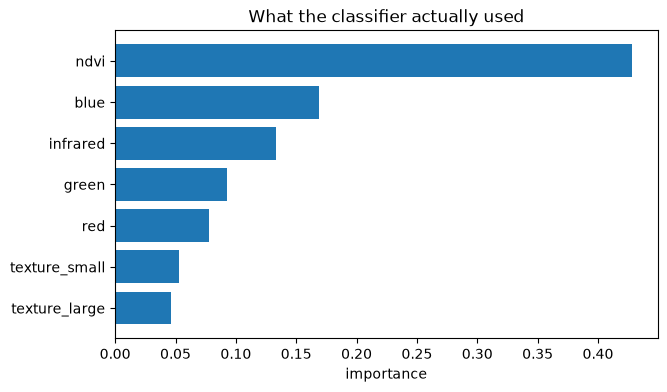

In [8]:
importances = model.feature_importances_

# Sorted from most to least important.
order = np.argsort(importances)[::-1]

print("What the model relied on:")
for position in order:
    print("  ", FEATURE_NAMES[position], "=", round(importances[position], 3))

# Reversed so the largest bar appears at the top.
sorted_names = []
sorted_values = []
for position in order:
    sorted_names.append(FEATURE_NAMES[position])
    sorted_values.append(importances[position])

sorted_names.reverse()
sorted_values.reverse()

plt.figure(figsize=(7, 4))
plt.barh(sorted_names, sorted_values)
plt.xlabel("importance")
plt.title("What the classifier actually used")

plt.savefig(config.FIGURES_FOLDER / "03_feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()

In [9]:
import joblib

joblib.dump(model, config.MODEL_FILE)
print("Saved to", config.MODEL_FILE)

Saved to C:\Users\Jamie\Developer\canopy-remote-sensing\canopy_model.joblib
